<a id="1"></a>
## **Objective of the notebook**

I just went through **code section of the competition** and found some **really amazing notebooks** that pretty much expressed everything and "said it all" (using the Hidden Gems dataset and the META Kaggle dataset).

**The goal** of this notebook is to **add something new** (that hasn't been discussed in the existing competition notebooks), and you'll see that it's a relatively short one. I looked over the Hidden Gems dataset and attempted to think of **something new** to add to the existing notebooks (which, again, are excellent and are gems in and of themselves).

- **The first** thing is that I attempted to use the **two columns** in the hidden gems dataset that, in my opinion, are the **most important**: the **review** and **title** columns (since they can help you understand what each notebook is about and what topic is discussed):  
I created a **NLP task**: how to find **similar notebooks** when I have a **specific notebook** dealing with a subject for which I want to have other ways of dealing (multiple notebooks) but it is also a "hidden gem."

- **The second** point, which is **difficult to handle** and currently **reaches its limits** with all of the **available data** now, is to determine whether the decision to choose and label these specific notebooks as "hidden gems" is a **right, fair, and unbiased** one. The steps to solve this are detailed in the **last paragraph**.

<a id="2"></a>
## **Looking for a specific hidden gem💎?**

#### **1-Sentence Transformers SBERT: Some background and context...**

To answer this question: **Looking for a specific hidden gem💎?**, I used **sentence-transformers 2019**. I provide some background and context for those who are encountering the terms for the first time:

- **Transformer models** had one issue when building **sentence vectors**: Transformers work using word or token-level embeddings, not sentence-level embeddings.

- Before **sentence transformers**, the approach to calculating accurate sentence similarity with BERT was to use a cross-encoder structure. This meant that we would pass two sentences to BERT, add a classification head to the top of BERT and use this to output a similarity score,

- This **cross-encoder** network does produce very accurate similarity scores, but it’s **not scalable**. If we wanted to perform a **similarity search** through a small 100K sentence dataset, we would need to complete the cross-encoder inference computation 100K times
- To cluster sentences, we would need to compare all sentences in our 100K dataset, resulting in just under 500M comparisons(this is simply not realistic).

- Ideally, we need to **pre-compute** **sentence vectors** that **can be stored** and then used whenever required. If these vector representations are good, all we need to do is calculate the **cosine similarity** between each.

- With the original BERT(and other transformers), we can build a sentence embedding by averaging the values across all token embeddings output by BERT (if we input 512 tokens, we output 512 embeddings). Alternatively, we can use the output of the first [CLS] token..this gives us our sentence embeddings that can be stored and compared much faster...However, the accuracy is not good, and is worse than using averaged GloVe embeddings (which were developed in 2014).
- The **solution** to this lack of an accurate model with reasonable latency was designed in 2019 with the introduction of **sentence-BERT (SBERT)** and the **sentence-transformers library**.
- **SBERT** outperformed the previous state-of-the-art models for all common semantic textual similarity (STS) tasks (except a single dataset (SICK-R)).

- Thankfully for **scalability**, SBERT produces sentence embeddings, so we do not need to perform a whole inference computation for every sentence-pair comparison.

- The authors of SBERT demonstrated the **dramatic speed increase in 2019**. Finding the most similar sentence pair from 10K sentences took **65 hours with BERT**. With SBERT, **embeddings** are created in **5 seconds** and compared with **cosine similarity** in **0.01 seconds**.

Fore more details: 
- [sentence transformers paper](https://arxiv.org/abs/1908.10084)
- [sentence transformers documentation](https://www.sbert.net/)
- [sentence transformers on Hugging Face](https://huggingface.co/sentence-transformers)

#### **2- Excellent 💎 notebook, but I'm looking for something similar.. Can I get it quickly?...**

In [1]:
# Install libraries of transformers and sentence-transformers.
!pip install datasets transformers[sentencepiece]
!pip install sentence-transformers 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 KB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.2/212.2 KB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 KB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.0-py3-none-any.whl size=120747 sha256=2277521b4229939e4d85f39f81e645051472ed99599efbf45a27ed927fd76aaf
  Stored in directory: /root/.cache/pip/wheels/83/c0/df/b6873ab7aac3f2465aa9144b6b4c41c4391cfecc027c8b07e7
Successfully built sentence-transformers


In [2]:
import pandas as pd
import numpy as np

In [3]:
# loading hidden gems dataset
df_gems = pd.read_csv("../input/notebooks-of-the-week-hidden-gems/kaggle_hidden_gems.csv")
df_gems.head(3)

,vol,date,link_forum,link_twitter,notebook,author_kaggle,title,review,author_name,author_twitter,author_linkedin,notes
0,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/hansjoerg/glmnet-xgboos...,hansjoerg,"Glmnet, XGBoost, and SVM Using tidymodels",A well-structured and documented tutorial on h...,Hansjoerg,https://twitter.com/hansjoerg_me,NaN,NaN
1,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey,https://twitter.com/pandeyparul,https://www.linkedin.com/in/parul-pandey-a5498...,NaN
2,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/jonathanbouchet/u-s-com...,jonathanbouchet,U.S. Commercial Flights Tracker Map,Stunning maps are accompanied by lots of other...,Jonathan Bouchet,NaN,https://www.linkedin.com/in/jonathanbouchet,NaN


In [4]:
# I need the list of all the hidden gems titles to perform sentence similarity (based on the title).
list_title_notebooks = list(df_gems['title'])
list_title_notebooks[0:10]

['Glmnet, XGBoost, and SVM Using tidymodels',
 'Breathe India: COVID-19 effect on Pollution',
 'U.S. Commercial Flights Tracker Map',
 'Unbiased Look on Brazil Wildfires',
 'MNIST 2D t-SNE with Rapids',
 'How good does your chocolate taste?',
 'The 12 Different Types of Kagglers',
 'Shifterator analysis on Animal Crossing reviews',
 'NYC Schools Race, Attendance Economy',
 'A deep learning of Deep Learning']

In [5]:
# Loading the sentence-transformer model 
# For more details,see : https://huggingface.co/sentence-transformers/all-mpnet-base-v2

from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

Downloading:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/190 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/10.1k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/571 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

Downloading:   0%|          | 0.00/239 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/466k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/363 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/13.1k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [6]:
# getting the sentence encodings
sentence_embeddings = model.encode(list_title_notebooks)

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

In [7]:
# Checking the shape of the embeddings
sentence_embeddings.shape

(300, 768)

**A- Which is the most similar notebook to the 1st 💎 hidden gem?**

In [8]:
# Calculate the cosine similarity between the 1st 💎 notebook and all the others.
from sklearn.metrics.pairwise import cosine_similarity

cos_sim1 = cosine_similarity([sentence_embeddings[0]],sentence_embeddings[0:])
cos_sim1[0][0:10]

array([1.        , 0.04815973, 0.01951388, 0.06649914, 0.19084898,
       0.07988057, 0.11174599, 0.07974671, 0.08700903, 0.1484567 ],
      dtype=float32)

In [9]:
df_gems['sim_💎_one']= cos_sim1[0]
df_gems.head(3)

,vol,date,link_forum,link_twitter,notebook,author_kaggle,title,review,author_name,author_twitter,author_linkedin,notes,sim_💎_one
0,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/hansjoerg/glmnet-xgboos...,hansjoerg,"Glmnet, XGBoost, and SVM Using tidymodels",A well-structured and documented tutorial on h...,Hansjoerg,https://twitter.com/hansjoerg_me,NaN,NaN,1.000000
1,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey,https://twitter.com/pandeyparul,https://www.linkedin.com/in/parul-pandey-a5498...,NaN,0.048160
2,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/jonathanbouchet/u-s-com...,jonathanbouchet,U.S. Commercial Flights Tracker Map,Stunning maps are accompanied by lots of other...,Jonathan Bouchet,NaN,https://www.linkedin.com/in/jonathanbouchet,NaN,0.019514


In [10]:
# Extract the most similar 💎 notebook to the first 💎 notebook
sim_noteb_1st = df_gems.sort_values('sim_💎_one').tail()[-2:]
sim_noteb_1st

,vol,date,link_forum,link_twitter,notebook,author_kaggle,title,review,author_name,author_twitter,author_linkedin,notes,sim_💎_one
172,58,2021-06-15,https://www.kaggle.com/general/246518,https://twitter.com/heads0rtai1s/status/140483...,https://www.kaggle.com/jessemostipak/getting-s...,jessemostipak,Getting started with {tidymodels} and xgboost,A well explained intro to leveraging the power...,Jesse Mostipak,https://twitter.com/kierisi,NaN,NaN,0.628961
0,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/hansjoerg/glmnet-xgboos...,hansjoerg,"Glmnet, XGBoost, and SVM Using tidymodels",A well-structured and documented tutorial on h...,Hansjoerg,https://twitter.com/hansjoerg_me,NaN,NaN,1.000000


- Below, I extracted the url of the two notebooks (the **1st** hidden gem and its **most similar hidden gem**)
- You can check them: Yes, it is pretty much the same subject! (the 1st is about **tidymodels and xgboost** and the other is about **Glmnet, XGBoost, and SVM Using tidymodels**)
- One is the **1st** hidden gem and the other is the **173th** hidden gem.

In [11]:
list(sim_noteb_1st['notebook']) 

['https://www.kaggle.com/jessemostipak/getting-started-with-tidymodels-and-xgboost',
 'https://www.kaggle.com/hansjoerg/glmnet-xgboost-and-svm-using-tidymodels']

**B- The 4th hidden gem is fantastic "Unbiased Look on Brazil Wildfires". I'd like to delve deeper into this topic. Could I find another similar 💎 hidden gem?**

In [12]:
# It is Pretty simple now! 
cos_sim4 = cosine_similarity([sentence_embeddings[3]],sentence_embeddings[0:])
df_gems['sim_💎_4']= cos_sim4[0]

sim_sen_4= df_gems.sort_values('sim_💎_4').tail()[-2:]
sim_sen_4

,vol,date,link_forum,link_twitter,notebook,author_kaggle,title,review,author_name,author_twitter,author_linkedin,notes,sim_💎_one,sim_💎_4
39,14,2020-08-11,https://www.kaggle.com/general/173943,https://twitter.com/heads0rtai1s/status/129321...,https://www.kaggle.com/captcalculator/wildfire...,captcalculator,Wildfire Exploratory Analysis,A detailed analysis of extensive US wildfire d...,Troy Walters,https://twitter.com/CaptCalculator,https://www.linkedin.com/in/troywalters,NaN,0.049656,0.626096
3,2,2020-05-19,https://www.kaggle.com/general/152383,https://twitter.com/heads0rtai1s/status/126279...,https://www.kaggle.com/andradaolteanu/unbiased...,andradaolteanu,Unbiased Look on Brazil Wildfires,A well-focused analysis on a globally importan...,Andrada Olteanu,https://twitter.com/andradaolteanuu,https://www.linkedin.com/in/andrada-olteanu-38...,NaN,0.066499,1.000000


- Below, I extracted the url of the two notebooks (the **4th** hidden gem and its **most similar hidden gem**)
- You can check them: the 4th 💎 is about **Unbiased Look on Brazil Wildfires** and the other is about **Wildfire Exploratory Analysis**)
- One is the **4th** hidden gem and the other is the **40th** hidden gem.

In [13]:
list(sim_sen_4['notebook']) 

['https://www.kaggle.com/captcalculator/wildfire-exploratory-analysis',
 'https://www.kaggle.com/andradaolteanu/unbiased-look-on-brazil-wildfires']

**C- The 101st 💎 is an analysis study of San Francisco crimes. "What gets you arrested in San Francisco?", Is it possible to find similar 💎 notebooks?**

In [14]:
# Of course, it is pretty simple now
cos_sim101 = cosine_similarity([sentence_embeddings[100]],sentence_embeddings[0:])
df_gems['sim_💎_101']= cos_sim101[0]

sim_sen_101= df_gems.sort_values('sim_💎_101').tail()[-3:]
sim_sen_101

,vol,date,link_forum,link_twitter,notebook,author_kaggle,title,review,author_name,author_twitter,author_linkedin,notes,sim_💎_one,sim_💎_4,sim_💎_101
89,30,2020-12-01,https://www.kaggle.com/general/200738,https://twitter.com/heads0rtai1s/status/133383...,https://www.kaggle.com/thedatabeast/understand...,thedatabeast,Understanding the extent of police abuse in th...,A thoughtful and methodical analysis of US pol...,Ramshankar Yadhunath,https://twitter.com/thedatacrack,NaN,"The 30th episode of Hidden Gems features ""Comm...",0.057129,0.129620,0.349702
63,22,2020-10-06,https://www.kaggle.com/general/189088,https://twitter.com/heads0rtai1s/status/131353...,https://www.kaggle.com/harriken/police-dogs-an...,harriken,Police Dogs and Grey hair will save you from jail,A well-designed tour of a criminal justice dat...,Jose Berengueres,https://twitter.com/jj_berens,http://ae.linkedin.com/in/berengueres,NaN,0.177673,0.066620,0.369348
100,34,2020-12-29,https://www.kaggle.com/general/207416,https://twitter.com/heads0rtai1s/status/134400...,https://www.kaggle.com/shootboyxxx/what-gets-y...,shootboyxxx,What gets you arrested in San Francisco,This work provides an arrestingly developed st...,bestmodel,NaN,NaN,NaN,0.079478,0.103535,1.000000


- Below, I extracted the url of three notebooks (the **101st** hidden gem and its **two most similar hidden gems**)
- You can check them: the 101st 💎 is about **San Francisco crimes** and the two others are about **Police Dogs Safety** and **Understanding the extent of police abuse in the US**)
- One is the **101st** hidden gem and the others are the **64th** and **90th** hidden gems.

In [15]:
list(sim_sen_101['notebook']) 

['https://www.kaggle.com/thedatabeast/understanding-the-extent-of-police-abuse-in-the-us',
 'https://www.kaggle.com/harriken/police-dogs-and-grey-hair-will-save-you-from-jail',
 'https://www.kaggle.com/shootboyxxx/what-gets-you-arrested-in-san-francisco']

**D- Conclusion(looking for something similar...):**  
Each time you take a hidden gem 💎 to learn, you can always find similar hidden gem 💎 notebooks (either discussing the **same model**, or dealing with **the same subject**, etc.), just **repeat the process above**.

<a id="3"></a>
## **Sentiment Analysis: Check that all of the reviews are positive**

In [16]:
# Loading a pretrained classifier for "sentiment-analysis", from hugging Face
from transformers import pipeline

classifier = pipeline(model= "siebert/sentiment-roberta-large-english")


Downloading:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/687 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/256 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/780k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/446k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [17]:
sentiment = classifier(list(df_gems['review']))
sentiment[0:20]

[{'label': 'POSITIVE', 'score': 0.9988033771514893},
 {'label': 'POSITIVE', 'score': 0.9988337159156799},
 {'label': 'POSITIVE', 'score': 0.9989245533943176},
 {'label': 'POSITIVE', 'score': 0.9989340901374817},
 {'label': 'POSITIVE', 'score': 0.9988264441490173},
 {'label': 'POSITIVE', 'score': 0.998892605304718},
 {'label': 'POSITIVE', 'score': 0.998414158821106},
 {'label': 'POSITIVE', 'score': 0.9987092018127441},
 {'label': 'POSITIVE', 'score': 0.9988964796066284},
 {'label': 'POSITIVE', 'score': 0.9987723231315613},
 {'label': 'POSITIVE', 'score': 0.9989277720451355},
 {'label': 'POSITIVE', 'score': 0.9988162517547607},
 {'label': 'POSITIVE', 'score': 0.9987918734550476},
 {'label': 'POSITIVE', 'score': 0.9988791346549988},
 {'label': 'POSITIVE', 'score': 0.9989062547683716},
 {'label': 'POSITIVE', 'score': 0.9989122152328491},
 {'label': 'POSITIVE', 'score': 0.9989224672317505},
 {'label': 'POSITIVE', 'score': 0.9988920092582703},
 {'label': 'POSITIVE', 'score': 0.99890685081481

In [18]:
scores=[]
for item in sentiment:
    scores.append(item['score'])

df_gems['scores'] = scores

- Check that all of the reviews are positive
- **Yes**,as you see, below, **all the socres are greater than 0.5**
- It is self-evident, but just to be sure.

In [19]:
# Yes all the scores are greater than 0.5, so all the reviews are positive
sum(df_gems['scores']<0.5)

0

<a id="4"></a>
## **Are the💎Fairly "distributed?"(+ suggestions)**

I realized that dealing with this just using the available datasets is currently **challenging** and **reaches its limits**.  

First, let me explain what I mean by **"Fairly distributed"**.
- I'd like to look into **who created these hidden gems💎** (in terms of percentage): are they just GrandMasters or Kaggle staff, for example?
- Next, I'd like to know about **gender distribution**: do most hidden gems originate from **women** or **men**, or are they evenly distributed?
- Then I'd like to know where these hidden gems contributors originate from: **do we have enough diversity**?

**==>** All of the previous three points can be handled if we have the **data** (it turns out that we only have data on **user performance** in the Meta Kaggle dataset, **no data on gender or country of origin**), so the **last two points are now impossible to process**. I believe **Kaggle should now consider including these informations** (which will help them **at the same time** to reduce **fake profiles** and **fight against fake upvotes** etc. by requiring, for example, an **identity document** when creating the account, while collecting **country** and **gender**).

- Then there's a an idea that occurred to me (just a thought). I'm just trying to figure out and analyse **what "fairly distributed" could mean**. If you wish, you can think with me. You're bound to have some further suggestions. I'm thinking about all the **other hidden gems** that **Martin hasn't read or discovered** (first and foremost, **he's human**, and he can't read everything on Kaggle), as well as **the possibility** that his judgment is skewed (I repeat, this is not a judgement, I am in the process of brainstorming). For example, **his tastes in data science** may influence him to **prefer** notebooks that **deal** with **EDA (Exploratory Data Analysis)** over others (in percent )....

Below, I will handle only **the first point** I mentioned above (the **only one** among the **4 points** that could be handled with the **data available** now).

In [20]:
# Loading the data about users from the Meta Kaggle dataset
# Merge the hidden gem dataset with the users' dataset.

df_users = pd.read_csv('../input/meta-kaggle/Users.csv')

df_merged = pd.merge(df_gems, df_users, left_on="author_kaggle", right_on="UserName")

In [21]:
df_merged.head(3)

,vol,date,link_forum,link_twitter,notebook,author_kaggle,title,review,author_name,author_twitter,...,notes,sim_💎_one,sim_💎_4,sim_💎_101,scores,Id,UserName,DisplayName,RegisterDate,PerformanceTier
0,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/hansjoerg/glmnet-xgboos...,hansjoerg,"Glmnet, XGBoost, and SVM Using tidymodels",A well-structured and documented tutorial on h...,Hansjoerg,https://twitter.com/hansjoerg_me,...,NaN,1.00000,0.066499,0.079478,0.998803,4208588,hansjoerg,Hansjoerg,12/15/2019,1
1,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey,https://twitter.com/pandeyparul,...,NaN,0.04816,0.202300,0.077385,0.998834,391404,parulpandey,Parul Pandey,07/26/2015,4
2,38,2021-01-26,https://www.kaggle.com/general/214418,https://twitter.com/heads0rtai1s/status/135411...,https://www.kaggle.com/parulpandey/nifty-data-eda,parulpandey,Nifty data EDA,A well-structured exploration of Indian stockm...,Parul Pandey,https://twitter.com/pandeyparul,...,NaN,0.19174,0.014486,0.008863,0.998876,391404,parulpandey,Parul Pandey,07/26/2015,4


In [22]:
# fill The real performance column with "strings" using map function
df_merged['PerformanceTier'] = df_merged['PerformanceTier'].map({0: "Novice",1: "Contributor",2: "Expert",3: "Master",4: "Grandmaster",5: "Kaggle Team"})

In [23]:
# Who are the hidden gems  (in terms of number)
counts= df_merged['PerformanceTier'].value_counts()
counts

Expert         84
Master         76
Contributor    55
Grandmaster    53
Novice         26
Kaggle Team     5
Name: PerformanceTier, dtype: int64

In [24]:
# The hidden gems  (in terms of %)
df_counts = pd.DataFrame(data= np.round(np.array(list(counts))*100/sum(counts)),index= counts.index, columns=['Percentage of Hidden gems (%)'])
df_counts

,Percentage of Hidden gems (%)
Expert,28.0
Master,25.0
Contributor,18.0
Grandmaster,18.0
Novice,9.0
Kaggle Team,2.0


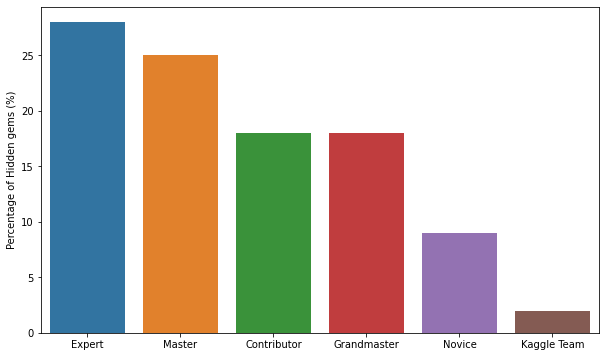

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.figure(figsize= (10,6))
sns.barplot(x = df_counts.index ,y = 'Percentage of Hidden gems (%)', data = df_counts)
plt.show()

**Conclusion**    
We notice that **majority of the hidden gems** are **neither GrandMaster nor Kaggle staff**, which is the **only point** (from 4 previous points) I **can currently handle** in this paragraph "Are the💎Fairly "distributed?"(+ suggestions)". For more details, see the beginning of this paragraph.  
The percentages show that, based on this **unique point**, the 💎 are **"distributed" fairly and reasonably btween kagglers**.